Nome: Luís Fernando Silva Lima

RA: 298966

Curso: Engenharia Elétrica (Mestrado)



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [1]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torchvision.transforms import v2
from torchmetrics import Accuracy
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST

%load_ext tensorboard

In [3]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [4]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 7
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


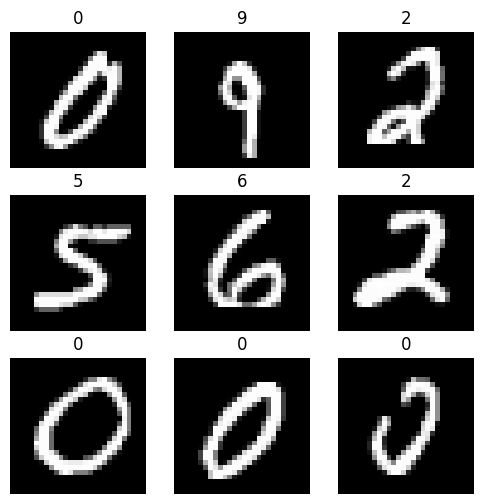

In [5]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 0
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


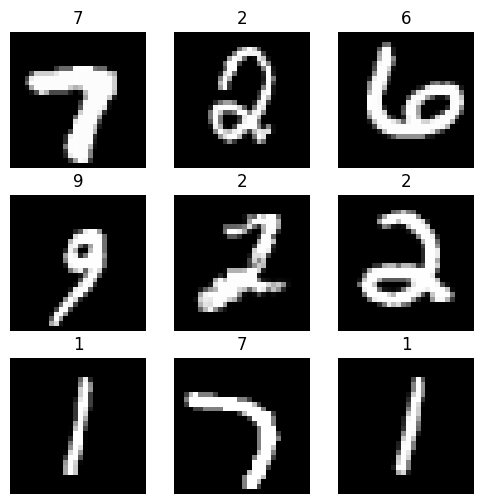

In [6]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA: O **torchvision.transforms.ToTensor** transforma uma PIL Image ou um numpy.ndarray no intervalo [0, 255] para um tensor float no intervalo [0.0, 1.0]. 

Como o tensor tem dimensões [1, 28, 28] porque é uma imagem em grayscale é desnecessário trabalhar com essa dimensão adicional, então é utilizado o .squeeze() para retirar essa dimensão "1" e sobrar apenas o tensor [28, 28], o que é equivalente ao anterior.

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [7]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 1 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 1
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [8]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:905: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


Shape do batch: torch.Size([100, 1, 28, 28])


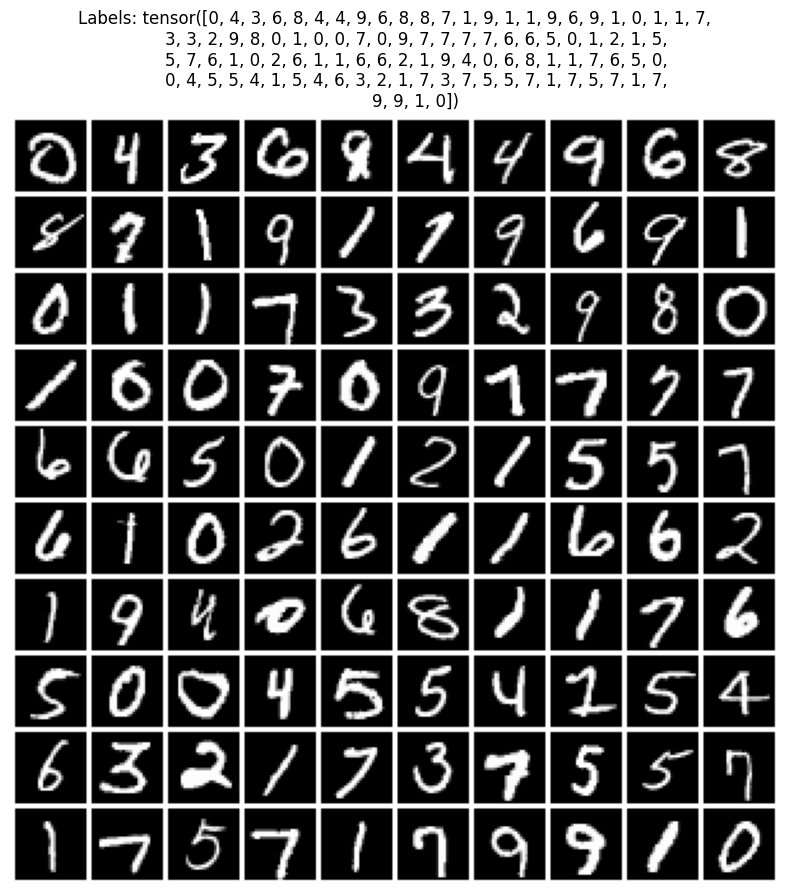

In [9]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [10]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

RESPOSTA: 
- Conv2d: Ela procura por padrões básicos como bordas horizontais, verticais e texturas simples, nesse caso há a redução da imagem para começar a condensar a informação.

- BatchNorm2d: Normaliza as saídas da convolução evitando que os valores fiquem grandes demais ou pequenos demais, o que ajuda a tornar o treinamento muito mais rápido e de forma estável.

- ReLU: Função de ativação ReLU.

- MaxPool2d: Ela reduz a dimensão espacial de (14x14) para (7x7), mantendo apenas a característica mais forte de cada região. 


Foi modificado o número de canais de entrada porque a imagem possui 1 canal e a Resnet-18 é projetada para imagens RGB (3 canais). Além disso, como há apenas 10 classes no dataset ocorreu a alteração na camada de saída linear para tal valor já que a Resnet-18 possui 1000 neurônios na camada de saída e portanto podia fazer a classificação entre 1000 classes.

### Resumo do modelo

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28))

cpu
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, porque as três primeiras camadas possuem saídas com dimensões (-1, 64, 14, 14) e a quarta camada tem saída com dimensões (-1, 64, 7, 7)?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

RESPOSTA: As camadas 1-3 (Conv2d, BatchNorm, ReLU) mantêm o tamanho 14x14 por causa do padding=(3, 3) que compensa o tamanho do kernel, preservando a resolução original. Porém, na camada 4 (MaxPool2d) é realizado o pooling, e como é utilizado um filtro 2x2 (stride = 2) em cada bloco de 4 pixels é extraído apenas o maior valor o que corta a altura e a largura pela metade.

1. Primeira camada (Conv2d: 1-1): **3136 parâmetros**
- parâmetros = (kernel * canais_de_entrada * canais_de_saída) = (7 * 7 * 1 * 64) = **3136 parâmetros**

2. BatchNorm2d (1-2): **128 parâmetros**
- parâmetros = (número_de_canais * 2) = (64 * 2) = **128 parâmetros**

3. Camadas Internas (Conv2d: 3-1): **36864 parâmetros**
- parâmetros = (kernel * número de canais * canais_de_saída) = (3 * 3 * 64 * 64) = **36864 parâmetros**

4. Camadas ReLU e MaxPool
- ReLU: é a função de ativação e portanto, **não aumenta a quantidade de parâmetros treináveis** (pesos);
- MaxPool: Apenas seleciona o valor máximo em uma janela e **não aumenta a quantidade de pesos**.

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [13]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [18]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 1
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\lfern\github-classroom\UNICAMP-EA979\2026s1-pi05-cnn-luisso2\logs exists and is not empty.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\pytorch_lightning\trainer\connectors\data_
connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [20]:
%tensorboard --logdir lightning_logs

Reusing TensorBoard on port 6006 (pid 8120), started 1 day, 9:25:38 ago. (Use '!kill 8120' to kill it.)

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [21]:
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

model = TrainMNIST.load_from_checkpoint(baseline_model, hparams=hparams, map_location='cpu').eval()

# Initialize validation data
data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs\Test_ResNet_1-epoch=9-val_acc=0.99.ckpt


c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


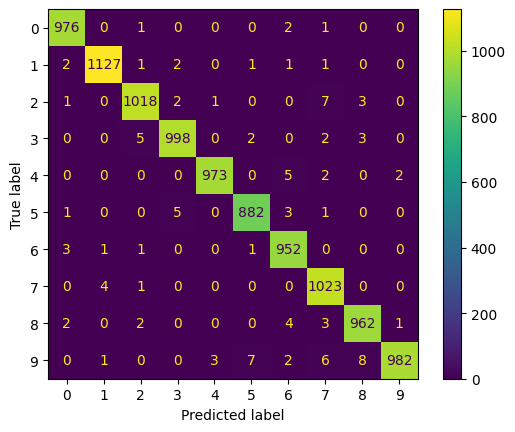

In [22]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

##### Para esse item busquei a utilização de duas redes neurais: uma pré-treinada e outra inicializada com pesos aleatórios. A primeira é a ResNet-18, uma arquitetura de rede neural convolucional profunda que foi pré-treinada em um grande conjunto de dados (ImageNet) utilizada anteriormente. A segunda também é uma ResNet-18 inicializada com pesos aleatórios, ou seja, sem pré-treinamento. Ambas as redes foram treinadas e avaliadas no conjunto de dados DermaMNIST para comparar seu desempenho.

#### Primeiro houve a importação do dataset, seguido do pré-processamento e depois a separação entre treinamento, validação e teste os quais foram transformados para TensorDataset

In [25]:
#Função para corrigir o formato das imagens e normalizar [0, 1]
def fix_shape_and_scale(imgs):
    t = torch.tensor(imgs).permute(0, 3, 1, 2)
    return t.float() / 255.0 

train_dataset_base = DermaMNIST(
    split="train",
    download=True
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True
)

#Train+Val
train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])


#Test
test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])

#Labels

train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

train_dataset = TensorDataset(fix_shape_and_scale(train_imgs), torch.tensor(train_labels).long())

val_dataset = TensorDataset(fix_shape_and_scale(val_imgs), torch.tensor(val_labels).long())

test_dataset = TensorDataset(fix_shape_and_scale(test_imgs), torch.tensor(test_labels).long())

Using downloaded and verified file: C:\Users\lfern\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\lfern\.medmnist\dermamnist.npz


In [26]:
#Dataset importado
print(train_dataset_base)
print()
print(test_dataset_base)
print()

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: C:\Users\lfern\.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datap

In [27]:
print("Imagens treinamento: ", train_imgs.shape)
print("Imagens validação: ", val_imgs.shape)
print("Imagens teste: ", test_imgs.shape)

Imagens treinamento:  (400, 28, 28, 3)
Imagens validação:  (100, 28, 28, 3)
Imagens teste:  (100, 28, 28, 3)


É possível concluir que são 400 imagens de treinamento, 100 para validação e 100 para teste, as quais são 28x28 bits e são em RGB (3 canais).

Tipo da Imagem: <class 'torch.Tensor'> | Tipo do Label: <class 'torch.Tensor'>
Shape da imagem: torch.Size([3, 28, 28])
Label numérico: 0
Maior valor de intensidade: 1
Menor valor de intensidade: 0


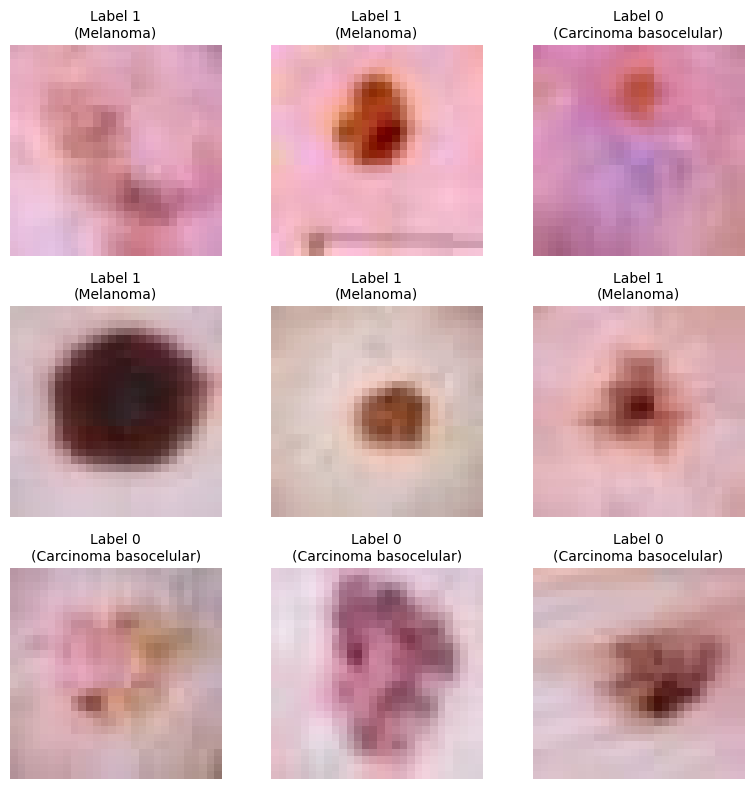

In [28]:
class_names = {0: "Carcinoma basocelular", 1: "Melanoma"}

#Selecionando uma amostra aleatória de treinamento
training_example = random.choice(train_dataset)

print(f'Tipo da Imagem: {type(training_example[0])} | Tipo do Label: {type(training_example[1])}')
print(f'Shape da imagem: {training_example[0].shape}')
print(f'Label numérico: {training_example[1].item()}')
#Valores pré-processados
print(f'Maior valor de intensidade: {torch.max(training_example[0]):.0f}')
print(f'Menor valor de intensidade: {torch.min(training_example[0]):.0f}')

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    #Selecionando uma amostra aleatória de treinamento
    img, label = random.choice(train_dataset)
    label_idx = label.item()

    plt.subplot(rows, cols, i)
    plt.title(f"Label {int(label_idx)}\n({class_names[label_idx]})", fontsize=10)
    plt.axis("off")
    
    plt.imshow(img.permute(1, 2, 0))

plt.tight_layout()
plt.show()

#### Foi então criada então a classe DermaDataModule, que é um LightningDataModule personalizado para lidar com os dados do DermaMNIST. Ela é responsável por organizar os dados de treinamento, validação e teste, e fornecer dataloaders para cada um desses conjuntos.

In [29]:
class DermaDataModule(pl.LightningDataModule):
    def __init__(self, train_data, val_data, test_data, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)
        
        self.train_set = train_data
        self.val_set = val_data
        self.test_set = test_data

    def setup(self, stage=None):
        pass

    def train_dataloader(self):
        return DataLoader(
            self.train_set, 
            batch_size=self.hparams.batch_size, 
            num_workers=self.hparams.nworkers, 
            shuffle=True,
            persistent_workers=(self.hparams.nworkers > 0),
            pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_set, 
            batch_size=self.hparams.batch_size, 
            num_workers=self.hparams.nworkers, 
            shuffle=False,
            persistent_workers=(self.hparams.nworkers > 0),
            pin_memory=True
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_set, 
            batch_size=self.hparams.batch_size, 
            num_workers=self.hparams.nworkers, 
            shuffle=False
        )

## Criação do modelo 1 - ResNet18 (Pré-treinada)

#### Definição dos parâmetros

Os valores abaixo foram definidos após testes com base na loss de validação

In [44]:
params = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 128,  # size of batch
           "nworkers": 2 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 2,  # number of classes
           "nin": 3,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in params.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 128
nworkers: 2
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


#### Adequação da ResNet pré-treinada para o DermaMNIST

Foi necessária a modificação da camada de saída para 2 saídas

In [47]:
model_1 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_1

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [48]:
num_ftrs = model_1.fc.in_features
model_1.fc = nn.Linear(num_ftrs, params['nout'])
model_1

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [49]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
summary(model_1, (3, 28, 28))

cpu
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

## Criação do modelo 2 - ResNet18 (Pesos aleatórios)

#### Definição dos parâmetros

Os valores abaixo foram definidos após testes com base na loss de validação

In [71]:
params_2 = {"experiment_name": "Test_ResNet_2",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 64,  # size of batch
           "nworkers": 2 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 2,  # number of classes
           "nin": 3,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in params_2.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_2
max_epochs: 10
batch_size: 64
nworkers: 2
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


#### Adequação da ResNet para o DermaMNIST

Foi necessária a modificação da camada de saída para 2 saídas

In [72]:
model_2 = models.resnet18(weights=None)

num_ftrs = model_2.fc.in_features
model_2.fc = nn.Linear(num_ftrs, 2)

In [73]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model_2.to(device)
summary(model_2, (3, 28, 28))

cpu
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          9,408
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

## Criação do Lighting Module

In [ ]:
class TrainDermaMNIST(pl.LightningModule):
    def __init__(self, params, model):
        super().__init__()

        self.save_hyperparameters(params)
        
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss()
        
        #Ajustando para 2 classes
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x)

    def classification_step(self, mode, batch):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss_fn(logits, y)
        
        preds = torch.argmax(logits, dim=1)

        if mode == "train":
            self.log("train_loss", loss, on_epoch=True, on_step=True, prog_bar=True)
            return loss
        
        elif mode == "val":
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, prog_bar=True)
            
        elif mode == "test":
            self.accuracy(preds, y)
            self.log("test_loss", loss, on_epoch=True)
            self.log("test_acc", self.accuracy, on_epoch=True)

    def training_step(self, batch, batch_idx):
        return self.classification_step("train", batch)

    def validation_step(self, batch, batch_idx):
        self.classification_step("val", batch)
        
    def test_step(self, batch, batch_idx):
        self.classification_step("test", batch)

    def configure_optimizers(self):
        #Escolhi AdamW, pois apresenta bons resultados em tarefas de classificação
        return AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

## Treinamento das duas redes

### 1. Treino da ResNet pré-treinada

In [67]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model_resnet = TrainDermaMNIST(params, model_1)
#model_resnet = model.float()
data = DermaDataModule(train_dataset, val_dataset, test_dataset, params)

os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",
                                       filename=params["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=params["max_epochs"], 
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in params.items():
    print(f'{k}: {v}')

trainer.fit(model_resnet, data)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 128
nworkers: 2
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss_fn  │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


### 2. Treino da ResNet com pesos aleatórios

In [74]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model_resnet_scratch = TrainDermaMNIST(params_2, model_2)
#model_resnet = model.float()
data = DermaDataModule(train_dataset, val_dataset, test_dataset, params_2)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=params_2["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=params_2["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in params_2.items():
    print(f'{k}: {v}')

trainer.fit(model_resnet_scratch, data)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Hyperparameters:

experiment_name: Test_ResNet_2
max_epochs: 10
batch_size: 64
nworkers: 2
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss_fn  │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


## Teste das duas redes neurais

#### Decidi criar uma função que pega o último log salvo com base no nome do experimento (load_latest_model) e outra função que retorna a predição de cada imagem de teste e seu respectivo label correto (collect_results)

In [75]:
#Busca o último checkpoint com base no nome do experimento
def load_latest_model(exp_name, base_architecture, hparams):
    pattern = os.path.join("logs", f"{exp_name}*.ckpt")
    checkpoints = glob(pattern)
    
    #Ordena por data de modificação e pega o último
    checkpoints.sort(key=os.path.getmtime)
    latest_ckpt = checkpoints[-1]

    #Carrega o LightningModule na CPU (Não estava conseguindo usar a GPU)
    model_lightning = TrainDermaMNIST.load_from_checkpoint(
        latest_ckpt,
        model=base_architecture,
        map_location=torch.device('cpu'),
        hparams=hparams
    )

    return model_lightning.eval()

#Percorre o dataloader e coleta os labels reais e suas predições
def collect_results(dataloader, model_eval):
    y_trues = []
    y_preds = []
    
    with torch.no_grad():
        for batch in dataloader:
            img, label = batch
            
            #Faz a predição
            logits = model_eval(img) 
            pred = torch.argmax(logits, dim=1)
            
            y_trues.extend(label.cpu().numpy())
            y_preds.extend(pred.cpu().numpy())

    return y_trues, y_preds

### Carregamento do último modelo treinado da ResNet pré-treinada e verificando a predição dos dados de teste

In [77]:
model_eval = load_latest_model("Test_ResNet_1", model_1, params)
data_module = DermaDataModule(train_dataset, val_dataset, test_dataset, params)
    
#Configurando o batch_size para 1 para avaliação individual
data_module.hparams["batch_size"] = 1
test_loader = data_module.test_dataloader()

y_trues_val_1, y_labels_val_1 = collect_results(test_loader, model_eval)

print(f"Total de amostras processadas: {len(y_trues_val_1)}")

c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
c:\Users\lfern\AppData\Local

Total de amostras processadas: 100


### Carregamento do último modelo treinado da ResNet com pesos aleatórios e verificando a predição dos dados de teste

In [79]:
model_eval = load_latest_model("Test_ResNet_2", model_2, params)
data_module = DermaDataModule(train_dataset, val_dataset, test_dataset, params)
    
#Configurando o batch_size para 1 para avaliação individual
data_module.hparams["batch_size"] = 1
test_loader = data_module.test_dataloader()

y_trues_val_2, y_labels_val_2 = collect_results(test_loader, model_eval)

print(f"Total de amostras processadas: {len(y_trues_val_2)}")

c:\Users\lfern\AppData\Local\Programs\Python\Python311\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
c:\Users\lfern\AppData\Local

Total de amostras processadas: 100


### Cálculo das métricas de desempenho (Precisão, recall e f1-score) e matriz de confusão

#### 1. ResNet pré-treinada

--- Relatório de Classificação ---
                           precision    recall  f1-score   support

Carcinoma basocelular (0)       0.89      0.96      0.92        50
             Melanoma (1)       0.96      0.88      0.92        50

                 accuracy                           0.92       100
                macro avg       0.92      0.92      0.92       100
             weighted avg       0.92      0.92      0.92       100



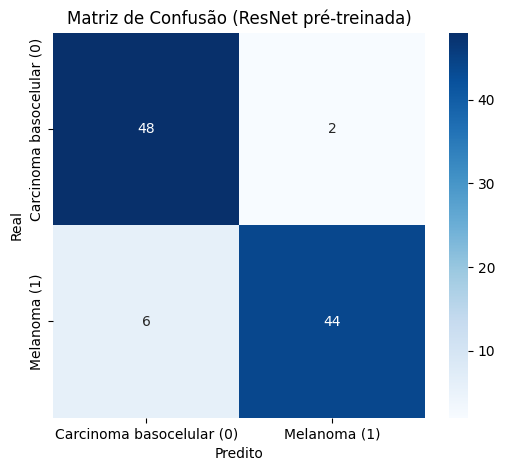

In [ ]:
target_names = ['Carcinoma basocelular (0)', 'Melanoma (1)']

print("--- Relatório de Classificação ---")
print(classification_report(y_trues_val_1, y_labels_val_1, target_names=target_names))

cm = confusion_matrix(y_trues_val_1, y_labels_val_1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão (ResNet pré-treinada)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

#### 2. ResNet com pesos aleatórios

--- Relatório de Classificação ---
                           precision    recall  f1-score   support

Carcinoma basocelular (0)       0.87      0.90      0.88        50
             Melanoma (1)       0.90      0.86      0.88        50

                 accuracy                           0.88       100
                macro avg       0.88      0.88      0.88       100
             weighted avg       0.88      0.88      0.88       100



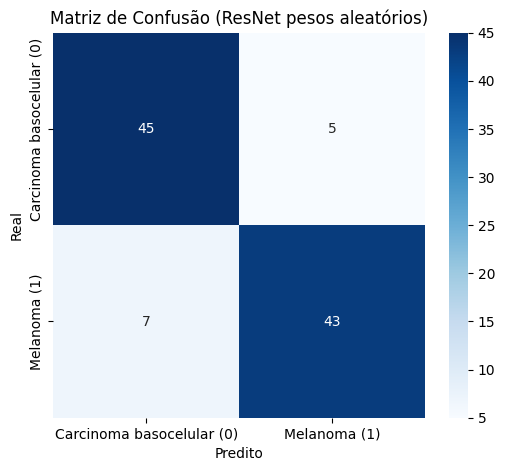

In [ ]:
target_names = ['Carcinoma basocelular (0)', 'Melanoma (1)']

print("--- Relatório de Classificação ---")
print(classification_report(y_trues_val_2, y_labels_val_2, target_names=target_names))

cm = confusion_matrix(y_trues_val_2, y_labels_val_2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matriz de Confusão (ResNet pesos aleatórios)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

### Por último fiz outra função para visualizar as predições

In [82]:
#Função para visualizar as predições do modelo em algumas amostras aleatórias do dataset
def visualize_predictions(dataset, model, num_examples=9):
    plt.figure(figsize=(12, 12))
    model.eval()
    
    #Seleciona índices aleatórios
    indices = random.sample(range(len(dataset)), num_examples)
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        
        with torch.no_grad():
            #Adiciona dimensão de batch [1, 3, 28, 28]
            output = model(img.unsqueeze(0)) 
            pred = torch.argmax(output, dim=1).item()
        
        img_display = img.permute(1, 2, 0).numpy()
        
        color = 'green' if pred == label else 'red'
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img_display)
        plt.title(f"Real: {target_names[label.item()]}\nPred: {target_names[pred]}", color=color)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

### Visualização das predições

#### 1. ResNet pré-treinada

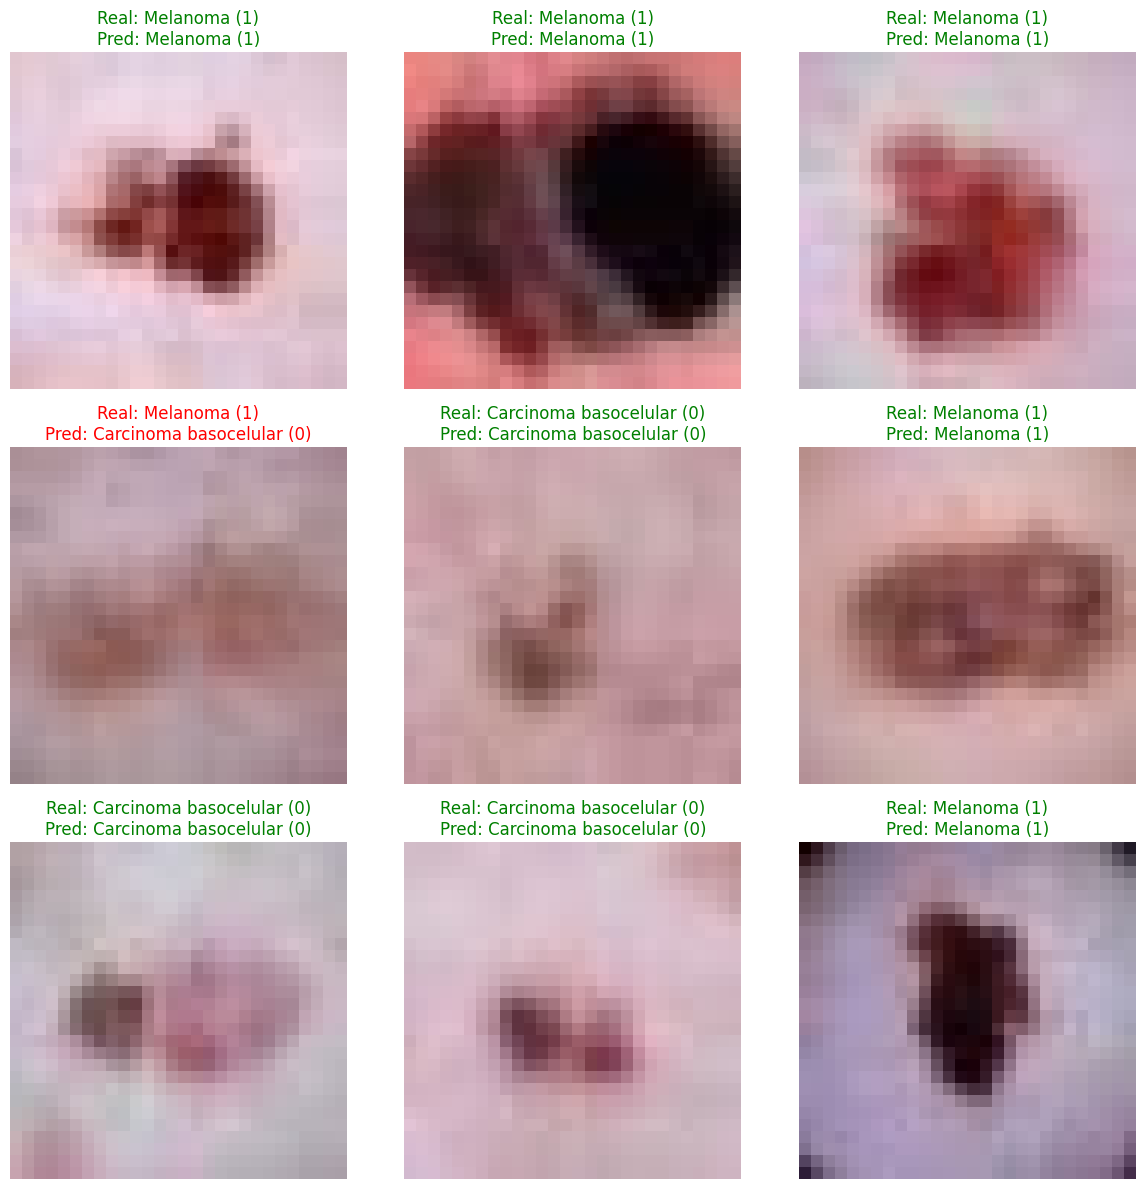

In [83]:
#Utilizando os dados de teste
visualize_predictions(test_dataset, model_1)

#### 2. ResNet com pesos aleatórios

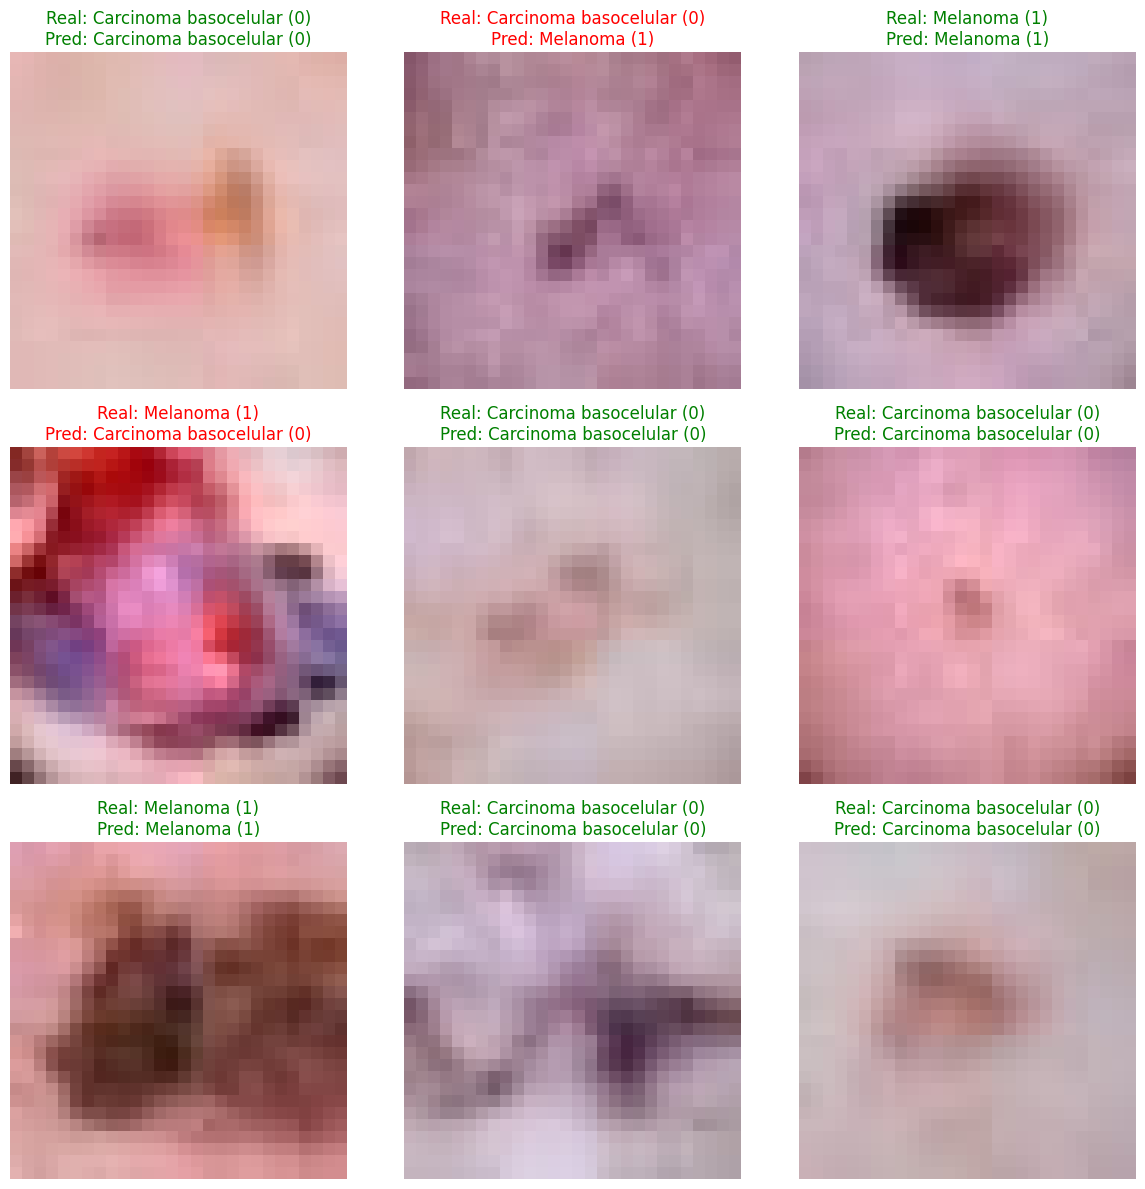

In [84]:
visualize_predictions(test_dataset, model_2)

O experimento realizado consistiu na comparação de duas abordagens de treinamento utilizando a arquitetura ResNet18 para a classificação binária de lesões de pele do dataset DermaMNIST, focando na distinção entre Carcinoma Basocelular e Melanoma. Nele foi comparado o desempenho da arquitetura ResNet18 em duas configurações: utilizando pesos pré-treinados e treinada do zero com pesos aleatórios.

Os resultados obtidos através das matrizes de confusão e dos relatórios de classificação demonstram uma superioridade clara da estratégia de Transfer Learning. A ResNet18 pré-treinada alcançou uma acurácia geral de 92%, apresentando um desempenho robusto na identificação de Carcinomas Basocelulares, com um recall de 0,96. Isso significa que o modelo foi capaz de identificar corretamente 48 dos 50 casos reais da doença, um fator crítico em diagnósticos oncológicos para evitar que pacientes doentes sejam liberados sem tratamento. Em relação ao Melanoma, a rede pré-treinada exibiu uma precisão de 0,96, confirmando que as predições positivas para esta classe são altamente confiáveis, embora seu recall de 0,88 indique uma margem ligeiramente maior de erro na detecção total desta patologia específica.

Por outro lado, a ResNet18 treinada do zero apresentou um desempenho inferior, com uma acurácia  de 88%. Embora este número seja considerado "ok" para uma rede profunda treinada sem conhecimento prévio em um conjunto de dados reduzido, a queda no recall para ambas as classes: 0,90 para Carcinoma e 0,86 para Melanoma, revela a dificuldade do modelo em aprender padrões morfológicos complexos a partir do zero. Enquanto a rede pré-treinada já possui filtros internos capazes de reconhecer bordas, texturas e geometrias universais, a rede inicializada aleatoriamente precisa gastar seus ciclos de processamento tentando aprender esses conceitos básicos simultaneamente às características específicas das lesões dermatológicas.

Portanto, a análise dos dados justifica a decisão de priorizar o uso de modelos pré-treinados para este tipo de tarefa. A diferença de 4% na acurácia global e a redução significativa no número de falsos negativos na rede pré-treinada confirmam que o aprendizado por transferência permite que o modelo extraia informações mais ricas de imagens pequenas como o do DermaMNIST (28x8), garantindo maior segurança clínica e eficiência computacional. 

## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.